# Anisotropic MeanFlow with α_t Interpolant

**Interpolant formulation:** `z_t = (1 - α_t) ⊙ x + α_t ⊙ ε`

where:
- `α_t = 0` for observed pixels (no noise, stays at data)
- `α_t = t` for masked pixels (interpolates from 0→1 as t goes from 0→1, i.e., from data→noise)
- `⊙` denotes element-wise (Hadamard) product
- At t=0: all pixels are data; At t=1: masked pixels are noise, observed pixels stay as data

**Key features:**
- Spatial conditioning: α_t is interpolated to match each U-Net layer resolution
- Fixed mask structure (box inpainting)
- Modified MeanFlow loss with Jacobian correction terms

In [1]:
# !pip install -q -U einops datasets matplotlib tqdm

%load_ext autoreload
%autoreload 2

import os
import torch
from torch import nn
from torch import einsum
import torch.nn.functional as F
import numpy as np
from torchvision.datasets import MNIST
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
from IPython import display
from tqdm import tqdm

import math
from inspect import isfunction
from functools import partial

from einops import rearrange

from training.networks_amf import SongUNet

plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['image.cmap'] = 'gray'

os.makedirs('save', exist_ok=True)

## Utility Functions

In [2]:
def grid(array, ncols=8):
    array = np.pad(array, [(0,0),(1,1),(1,1),(0,0)], 'constant')
    nindex, height, width, intensity = array.shape
    ncols = min(nindex, ncols)
    nrows = (nindex+ncols-1)//ncols
    r = nrows*ncols - nindex
    arr = np.concatenate([array]+[np.zeros([1,height,width,intensity])]*r)
    result = (arr.reshape(nrows, ncols, height, width, intensity)
              .swapaxes(1,2)
              .reshape(height*nrows, width*ncols, intensity))
    return np.pad(result, [(1,1),(1,1),(0,0)], 'constant')

class NextDataLoader(torch.utils.data.DataLoader):
    def __next__(self):
        try:
            return next(self.iterator)
        except:
            self.iterator = self.__iter__()
            return next(self.iterator)

def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

## Mask Generation

Generate binary masks where:
- `mask = 1`: observed pixels
- `mask = 0`: pixels to inpaint

**Random box sizes:** During training, box sizes are randomized from 1 pixel to the full image size for better generalization!

In [3]:
def generate_box_mask(batch_size, channels, height, width, box_size=16, device='cuda'):
    """
    Generate center box masks for inpainting.
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box)
    """
    mask = torch.ones(batch_size, channels, height, width, device=device)
    start = (height - box_size) // 2
    end = start + box_size
    mask[:, :, start:end, start:end] = 0
    return mask

def generate_random_box_mask(batch_size, channels, height, width, min_box_size=1, max_box_size=None, device='cuda'):
    """
    Generate center box masks with RANDOM box sizes for each sample in the batch.
    
    Args:
        batch_size: number of samples
        channels: number of channels
        height, width: image dimensions
        min_box_size: minimum box size (default: 1 pixel)
        max_box_size: maximum box size (default: full image size)
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box with random size per sample)
    """
    if max_box_size is None:
        max_box_size = min(height, width)
    
    masks = []
    for _ in range(batch_size):
        # Randomly sample box size for this sample
        box_size = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
        
        # Create mask for this sample
        mask = torch.ones(channels, height, width, device=device)
        start = (height - box_size) // 2
        end = start + box_size
        mask[:, start:end, start:end] = 0
        masks.append(mask)
    
    return torch.stack(masks, dim=0)

def generate_random_mask(batch_size, channels, height, width, mask_ratio=0.5, device='cuda'):
    """
    Generate random pixel masks for inpainting.
    
    Args:
        mask_ratio: proportion of pixels to mask
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked
    """
    mask = torch.rand(batch_size, channels, height, width, device=device)
    mask = (mask > mask_ratio).float()
    return mask

## Alpha Schedule and Interpolant

**Alpha schedule (Standard Diffusion Convention):**
- `α_t = (1 - mask) * t`
- Observed pixels (mask=1): `α_t = 0` (always at data)
- Masked pixels (mask=0): `α_t = t` (goes from 0→1, i.e., data→noise)

**Interpolant:**
- `z_t = (1 - α_t) ⊙ x + α_t ⊙ ε`
- At t=0: `z_0 = x` (all data)
- At t=1: `z_1 = mask ⊙ x + (1-mask) ⊙ ε` (observed=data, masked=noise)

**Velocity:**
- `dz_t/dt = -x·dα_t/dt + ε·dα_t/dt = (ε - x)·dα_t/dt`
- `dα_t/dt = (1 - mask)` (only masked pixels change)
- `v = (1 - mask) ⊙ (ε - x)`

In [4]:
def compute_alpha_t(t, mask):
    """
    Compute α_t from time and mask.

    Args:
        t: time parameter [B, 1, 1, 1], ranges from 0 (data) to 1 (noise)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked

    Returns:
        α_t: [B, C, H, W]
    """
    # α_t = (1 - mask) * t
    # Observed (mask=1): α_t = 0 (always at data)
    # Masked (mask=0): α_t = t (goes from data to noise)
    alpha_t = (1 - mask) * t
    return alpha_t

def sample_interpolant(x, t, mask, eps=None):
    """
    Sample from the interpolant: z_t = (1 - α_t) ⊙ x + α_t ⊙ ε

    Args:
        x: clean data [B, C, H, W]
        t: time [B, 1, 1, 1], ranges from 0 (data) to 1 (noise)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
        eps: noise (optional, will sample if not provided)

    Returns:
        z_t: interpolated sample [B, C, H, W]
        alpha_t: interpolation coefficients [B, C, H, W]
        eps: noise [B, C, H, W]
        v_true: true velocity field [B, C, H, W]
    """
    if eps is None:
        eps = torch.randn_like(x)

    # Compute α_t = (1 - mask) * t
    alpha_t = compute_alpha_t(t, mask)

    # Interpolant: z_t = (1 - α_t) ⊙ x + α_t ⊙ ε
    # At t=0: z_0 = x (all data)
    # At t=1: z_1 = mask⊙x + (1-mask)⊙ε (observed=data, masked=noise)
    z_t = (1 - alpha_t) * x + alpha_t * eps

    # Velocity: v = (ε - x) * dα_t/dt = (ε - x) * (1 - mask)
    drift = (eps - x)
    v_true = (1 - mask) * drift

    return z_t, alpha_t, eps, v_true, drift

## Jacobian Computation for Anisotropic Loss

We need to compute:
- `(∇_z u_θ) @ v`: Jacobian w.r.t. z in direction v
- `(∇_{α} u_θ) @ dα/dt`: gradient w.r.t. α in direction dα/dt

In [5]:
def compute_jacobian_correction(net, z_t, alpha_t, alpha_r, dalpha_dt, t, h, v_true):
    """
    Compute Jacobian correction terms using JVP.
    
    Args:
        net: neural network
        z_t: noisy sample [B, C, H, W]
        alpha_t: interpolation coefficients [B, C, H, W]
        dalpha_dt: time derivative of alpha [B, C, H, W]
        t: time [B, 1, 1, 1]
        h: auxiliary parameter [B, 1, 1, 1]
        v_true: true velocity [B, C, H, W]
    
    Returns:
        jvp_z: (∇_z u_θ) @ v_true
        jvp_alpha: (∇_{α} u_θ) @ dalpha_dt
    """
    # Take first channel of alpha_t for spatial conditioning
    alpha_spatial_t = alpha_t[:, :1, :, :]  # [B, 1, H, W]
    alpha_spatial_r = alpha_r[:, :1, :, :]  # [B, 1, H, W]

    # JVP w.r.t. z in direction v_true
    def u_wrapper_z(z):
        return net(z, alpha_spatial_t, alpha_spatial_r)
    _, jvp_z = torch.func.jvp(u_wrapper_z, (z_t,), (v_true,))
    
    # JVP w.r.t. alpha in direction dalpha_dt
    dalpha_spatial = dalpha_dt[:, :1, :, :]  # [B, 1, H, W]
    def u_wrapper_alpha(alpha):
        return net(z_t, alpha, alpha_spatial_r)
    _, jvp_alpha = torch.func.jvp(u_wrapper_alpha, (alpha_spatial_t,), (dalpha_spatial,))
    
    return jvp_z, jvp_alpha

## Anisotropic MeanFlow Loss

**Modified loss:**
```
u_target = v - (α_t - α_r) ⊙ [(∇_z u_θ) @ v + (∇_{α} u_θ) @ dα/dt]
loss = E[||u_θ - u_target||²]
```

In [6]:
class AnisotropicMeanFlowLoss:
    def __init__(
        self,
        P_mean=-0.4,
        P_std=1.0,
        noise_dist='logit_normal',
        data_proportion=0.75,
        norm_p=1.0,
        norm_eps=1.0,
        use_jacobian_correction=True,
    ):
        self.P_mean = P_mean
        self.P_std = P_std
        self.data_proportion = data_proportion
        self.norm_p = norm_p
        self.norm_eps = norm_eps
        self.noise_dist = noise_dist
        self.use_jacobian_correction = use_jacobian_correction

    def _logit_normal_dist(self, shape, device):
        rnd_normal = torch.randn(shape, device=device)
        return torch.sigmoid(rnd_normal * self.P_std + self.P_mean)

    def _uniform_dist(self, shape, device):
        return torch.rand(shape, device=device)

    def noise_distribution(self, shape, device):
        if self.noise_dist == 'logit_normal':
            return self._logit_normal_dist(shape, device)
        elif self.noise_dist == 'uniform':
            return self._uniform_dist(shape, device)
        else:
            raise ValueError(f"Unknown noise distribution: {self.noise_dist}")

    def __call__(self, net, images, masks):
        """
        Args:
            net: SpatialConditionedUnet
            images: clean images [B, C, H, W]
            masks: binary masks [B, C, H, W], 1 = observed, 0 = masked
        """
        x = images
        device = x.device
        batch_size = x.shape[0]
        shape = (batch_size, 1, 1, 1)

        # Sample t and r
        t = self.noise_distribution(shape, device)
        r = self.noise_distribution(shape, device)
        t, r = torch.max(t, r), torch.min(t, r)

        # Apply data proportion
        zero_mask = torch.arange(batch_size, device=device) < int(batch_size * self.data_proportion)
        zero_mask = zero_mask.view(shape)
        r = torch.where(zero_mask, t, r)

        # Sample from interpolant (sample_interpolant returns 5 values)
        z_t, alpha_t, eps, v_true, drift = sample_interpolant(x, t, masks)
        
        # Compute α_r
        alpha_r = compute_alpha_t(r, masks)
        
        # dα/dt = (1 - mask)
        dalpha_dt = (1 - masks)
        
        # Compute h = t - r
        h = t - r

        # Forward pass
        alpha_spatial_t = alpha_t[:, :1, :, :]  # [B, 1, H, W]
        alpha_spatial_r = alpha_r[:, :1, :, :]  # [B, 1, H, W]
        u_pred = net(z_t, alpha_spatial_t, alpha_spatial_r)
        
        # Compute target velocity
        if self.use_jacobian_correction:
            # Compute Jacobian correction
            jvp_z, jvp_alpha = compute_jacobian_correction(
                net, z_t, alpha_t, alpha_r, dalpha_dt, t, h, v_true
            )
            
            # Correction term: (α_t - α_r) ⊙ [(∇_z u) @ v + (∇_{α} u) @ dα/dt]
            jacobian_term = jvp_z + jvp_alpha
            correction = (alpha_t - alpha_r) * jacobian_term
            
            u_target = v_true - correction
        else:
            # Standard MeanFlow without correction
            u_target = v_true
        
        u_target = u_target.detach()

        # Compute loss with adaptive weighting
        unweighted_loss = (u_pred - u_target).pow(2).sum(dim=[1, 2, 3])
        
        with torch.no_grad():
            adaptive_weight = 1 / (unweighted_loss + self.norm_eps).pow(self.norm_p)

        loss = unweighted_loss * adaptive_weight
        return loss.mean()


In [ ]:
class AnisotropicFlowMap:
    def __init__(
        self,
        P_mean=-0.4,
        P_std=1.0,
        noise_dist='logit_normal',
        data_proportion=0.75,
        norm_p=1.0,
        norm_eps=1.0,
    ):
        self.P_mean = P_mean
        self.P_std = P_std
        self.data_proportion = data_proportion
        self.norm_p = norm_p
        self.norm_eps = norm_eps
        self.noise_dist = noise_dist

    def _logit_normal_dist(self, shape, device):
        rnd_normal = torch.randn(shape, device=device)
        return torch.sigmoid(rnd_normal * self.P_std + self.P_mean)

    def _uniform_dist(self, shape, device):
        return torch.rand(shape, device=device)

    def noise_distribution(self, shape, device):
        if self.noise_dist == 'logit_normal':
            return self._logit_normal_dist(shape, device)
        elif self.noise_dist == 'uniform':
            return self._uniform_dist(shape, device)
        else:
            raise ValueError(f"Unknown noise distribution: {self.noise_dist}")

    def __call__(self, net, images, masks):
        """
        Args:
            net: network with call net(x, alpha_source, alpha_target)
            images: clean images [B, C, H, W]
            masks: binary masks [B, C, H, W], 1 = observed, 0 = masked
        """
        x = images
        device = x.device
        batch_size = x.shape[0]
        shape = (batch_size, 1, 1, 1)

        # Sample t >= r (t is the noisy/source end for backward flow)
        t = self.noise_distribution(shape, device)
        r = self.noise_distribution(shape, device)
        t, r = torch.max(t, r), torch.min(t, r)

        # Apply data proportion: r=t for first data_proportion of batch (diagonal)
        zero_mask = torch.arange(batch_size, device=device) < int(batch_size * self.data_proportion)
        zero_mask = zero_mask.view(shape)
        r = torch.where(zero_mask, t, r)

        # Sample interpolant at t (backward-flow source: higher alpha = more noise)
        z_t, alpha_t, eps, v_true, drift = sample_interpolant(x, t, masks)

        # Compute α_r
        alpha_r = compute_alpha_t(r, masks)

        # --- Diagonal loss ---
        # Train net(z_t, alpha_t, alpha_t) to predict the instantaneous velocity v_true.
        # v_true = (1 - mask) * (eps - x): zero for observed pixels, nonzero for masked.
        alpha_spatial_t = alpha_t[:, :1, :, :]  # [B, 1, H, W]
        u_pred = net(z_t, alpha_spatial_t, alpha_spatial_t)
        loss_diag = ((1-masks) * u_pred - v_true).pow(2).sum(dim=[1, 2, 3])

        # --- Off-diagonal Lagrangian condition loss ---
        # Backward flow map: X_{t,r}(z_t) maps from source t (noisy) to target r (clean).
        #   X_{t,r}(z_t) = z_t - (alpha_t - alpha_r) * net(z_t, alpha_t, alpha_r)
        #
        # Lagrangian condition (differentiate w.r.t. TARGET alpha_r):
        #   dX_{t,r} / d(alpha_r)  ==  eta(X_{t,r}, alpha_r)   [evaluated on diagonal]
        #
        # We enforce this via a JVP in the direction d(alpha_r)/dr = (1 - mask),
        # matching the approach in compute_jacobian_correction.

        alpha_spatial_t_det = alpha_t[:, :1, :, :].detach()   # source alpha, no grad needed
        alpha_spatial_r_det = alpha_r[:, :1, :, :].detach()   # target alpha, JVP input
        z_t_det = z_t.detach()                                 # z_t is not a diff variable here

        # Tangent direction: d(alpha_r)/dr = (1 - mask), same as dalpha_dt
        dalpha = (1 - masks)[:, :1, :, :]  # [B, 1, H, W]

        def flow_map_fn(alpha_r_in):
            """Backward flow map as a function of the target alpha_r."""
            v = net(z_t_det, alpha_spatial_t_det, alpha_r_in)
            # X_{t,r}(z_t) = z_t - (alpha_t - alpha_r) * v
            return z_t_det - (alpha_spatial_t_det - alpha_r_in) * v

        # JVP gives (primal output X_tr, directional derivative dX_tr/d(alpha_r) @ dalpha)
        X_tr, dX_dalphar = torch.func.jvp(flow_map_fn, (alpha_spatial_r_det,), (dalpha,))

        # eta evaluated at the flowed position and TARGET time (diagonal call)
        v_rt = net(X_tr, alpha_spatial_r_det, alpha_spatial_r_det)

        # Lagrangian condition: dX_{t,r}/d(alpha_r) in direction dalpha == eta(X_tr, alpha_r)
        loss_lsd = (dX_dalphar - v_rt.detach()).pow(2).sum(dim=[1, 2, 3])

        # Adaptive weighting
        unweighted_loss = loss_diag + loss_lsd

        with torch.no_grad():
            adaptive_weight = 1 / (unweighted_loss + self.norm_eps).pow(self.norm_p)

        loss = unweighted_loss * adaptive_weight
        return loss.mean()


## Sampling/Inference

In [8]:
@torch.no_grad()
def sample(net, mask, x_observed=None, num_steps=1, device='cuda'):
    """
    Few-step (or one-step) sampling for inpainting.

    Convention: z_t = (1-α_t)⊙x + α_t⊙ε, where α_t = (1-mask)*t
    - At t=0: z_0 = x (all data)
    - At t=1: z_1 = mask⊙x + (1-mask)⊙ε (observed=data, masked=noise)

    We integrate from t=1 to t=0 in `num_steps` equal steps.

    Args:
        net: trained network (SongUNet)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
        x_observed: observed data [B, C, H, W] (optional, zeros if not provided)
        num_steps: number of integration steps (1 = one-step generation)
        device: device to use

    Returns:
        x0: generated/inpainted image [B, C, H, W]
    """
    B, C, H, W = mask.shape

    if x_observed is None:
        x_observed = torch.zeros(B, C, H, W, device=device)

    # Start from t=1: z_1 = mask⊙x_obs + (1-mask)⊙ε
    t_start = torch.ones(B, 1, 1, 1, device=device)
    alpha_start = compute_alpha_t(t_start, mask)
    eps = torch.randn(B, C, H, W, device=device)
    z = (1 - alpha_start) * x_observed + alpha_start * eps

    # Time steps from t=1 down to t=0
    t_values = torch.linspace(1.0, 0.0, num_steps + 1, device=device)

    for i in range(num_steps):
        t_cur = t_values[i].view(1, 1, 1, 1).expand(B, -1, -1, -1)
        t_next = t_values[i + 1].view(1, 1, 1, 1).expand(B, -1, -1, -1)
        dt = t_cur - t_next  # positive, since we go from 1→0

        alpha_t = compute_alpha_t(t_cur, mask)
        alpha_r = compute_alpha_t(t_next, mask)

        alpha_spatial_t = alpha_t[:, :1, :, :]
        alpha_spatial_r = alpha_r[:, :1, :, :]

        v_pred = net(z, alpha_spatial_t, alpha_spatial_r)

        # Euler step: z_{next} = z - v * dt
        z = z - v_pred * dt

    # Ensure observed pixels remain unchanged
    x_0 = mask * x_observed + (1 - mask) * z

    return x_0

## Training Loop

In [11]:
def train_anisotropic(
    net,
    max_iter,
    batch_size,
    optimizer_args,
    num_workers,
    val_interval,
    mask_type='random_box',  # 'box', 'random_box', or 'random'
    mask_ratio=0.5,
    box_size=16,
    min_box_size=1,
    max_box_size=None,
    val_batches=4,
    checkpoint_path='save/anisotropic_alpha_mf_flowmaps.pt',
    device='cuda',
    img_size=None,
):
    # Create train dataloader #
    train_dataset = MNIST(
        'data',
        train=True,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.Grayscale(),
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
        ]))),
        download=True
    )
    train_loader = NextDataLoader(
        train_dataset, batch_size, num_workers=num_workers, prefetch_factor=2, pin_memory=True
    )

    # Create test dataloader #
    test_dataset = MNIST(
        'data',
        train=False,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.Grayscale(),
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
        ]))),
        download=True
    )
    test_loader = NextDataLoader(
        test_dataset, batch_size, num_workers=num_workers, prefetch_factor=2, pin_memory=True
    )

    # Create optimizer and loss #
    optimizer = torch.optim.Adam(net.parameters(), **optimizer_args)
    # loss_fn = AnisotropicMeanFlowLoss()
    # val_loss_fn = AnisotropicMeanFlowLoss(use_jacobian_correction=False)
    loss_fn = AnisotropicFlowMap()
    val_loss_fn = AnisotropicFlowMap()

    # Fixed evaluation masks and images (from test set)
    if img_size is None:
        img_size = 28  # Default MNIST size
    if max_box_size is None:
        max_box_size = img_size  # Use img_size if not specified

    # Sample 8 random box sizes from range between min_box_size and max_box_size for evaluation
    eval_mask = []
    for _ in range(8):
        box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
        eval_mask.append(generate_box_mask(1, 1, img_size, img_size, box_size=box_size_i, device=device))
    eval_mask = torch.cat(eval_mask, dim=0)  # [8, 1, H, W]
    eval_images = next(test_loader)[0][:8].to(device)

    train_loss_history = []
    val_loss_history = []
    val_iters = []
    net.train()

    for i in tqdm(range(max_iter)):
        # Get batch
        x0 = next(train_loader)[0].to(device)

        # Generate masks with random box sizes
        if mask_type == 'random_box':
            masks = generate_random_box_mask(
                x0.shape[0], 1, img_size, img_size,
                min_box_size=min_box_size,
                max_box_size=max_box_size,
                device=device
            )
        elif mask_type == 'box':
            masks = generate_box_mask(x0.shape[0], 1, img_size, img_size, box_size, device)
        else:
            masks = generate_random_mask(x0.shape[0], 1, img_size, img_size, mask_ratio, device)

        # Compute loss
        loss = loss_fn(net, x0, masks)
        train_loss_history.append(loss.item())

        # Optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        if i % val_interval == 0:
            net.eval()

            # Compute validation loss over several test batches
            val_losses = []
            with torch.no_grad():
                for _ in range(val_batches):
                    val_x0 = next(test_loader)[0].to(device)
                    if mask_type == 'random_box':
                        val_masks = generate_random_box_mask(
                            val_x0.shape[0], 1, img_size, img_size,
                            min_box_size=min_box_size,
                            max_box_size=max_box_size,
                            device=device
                        )
                    elif mask_type == 'box':
                        val_masks = generate_box_mask(val_x0.shape[0], 1, img_size, img_size, box_size, device)
                    else:
                        val_masks = generate_random_mask(val_x0.shape[0], 1, img_size, img_size, mask_ratio, device)
                    val_loss = val_loss_fn(net, val_x0, val_masks)
                    val_losses.append(val_loss.item())
            avg_val_loss = np.mean(val_losses)
            val_loss_history.append(avg_val_loss)
            val_iters.append(i)

            # Generate inpainting samples
            with torch.no_grad():
                gen_x0 = sample(net, eval_mask, x_observed=eval_images, device=device)

            net.train()

            display.clear_output(wait=True)

            plt.figure(figsize=(20, 5))

            plt.subplot(1, 4, 1)
            orig_vis = eval_images.detach().permute(0, 2, 3, 1).cpu()
            plt.title('Original Images', fontsize=12)
            plt.imshow(grid(orig_vis).squeeze())
            plt.axis('off')

            plt.subplot(1, 4, 2)
            masked_vis = (eval_images * eval_mask).detach().permute(0, 2, 3, 1).cpu()
            plt.title('Masked (observed only)', fontsize=12)
            plt.imshow(grid(masked_vis).squeeze())
            plt.axis('off')

            plt.subplot(1, 4, 3)
            gen_x0_vis = gen_x0.detach().permute(0, 2, 3, 1).clamp(0, 1).cpu()
            plt.title(f'Inpainted (iter {i})', fontsize=12)
            plt.imshow(grid(gen_x0_vis).squeeze())
            plt.axis('off')

            plt.subplot(1, 4, 4)
            if i > 0:
                plt.plot(train_loss_history, alpha=0.3, color='blue', label='Train')
                plt.plot(val_iters, val_loss_history, color='red', linewidth=2, label='Val')
                plt.title('Loss')
                plt.xlabel('Iteration')
                plt.ylabel('Loss')
                plt.legend()
                plt.grid(True)

            plt.tight_layout()
            plt.show()
            print(f'Iter {i} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {avg_val_loss:.4f}')

    # Save checkpoint
    torch.save({
        'model': net.state_dict(),
        'optimizer': optimizer.state_dict(),
        'train_loss_history': train_loss_history,
        'val_loss_history': val_loss_history,
        'val_iters': val_iters,
    }, checkpoint_path)

    print(f'Training complete! Saved to {checkpoint_path}')
    return train_loss_history, val_loss_history

## Run Training

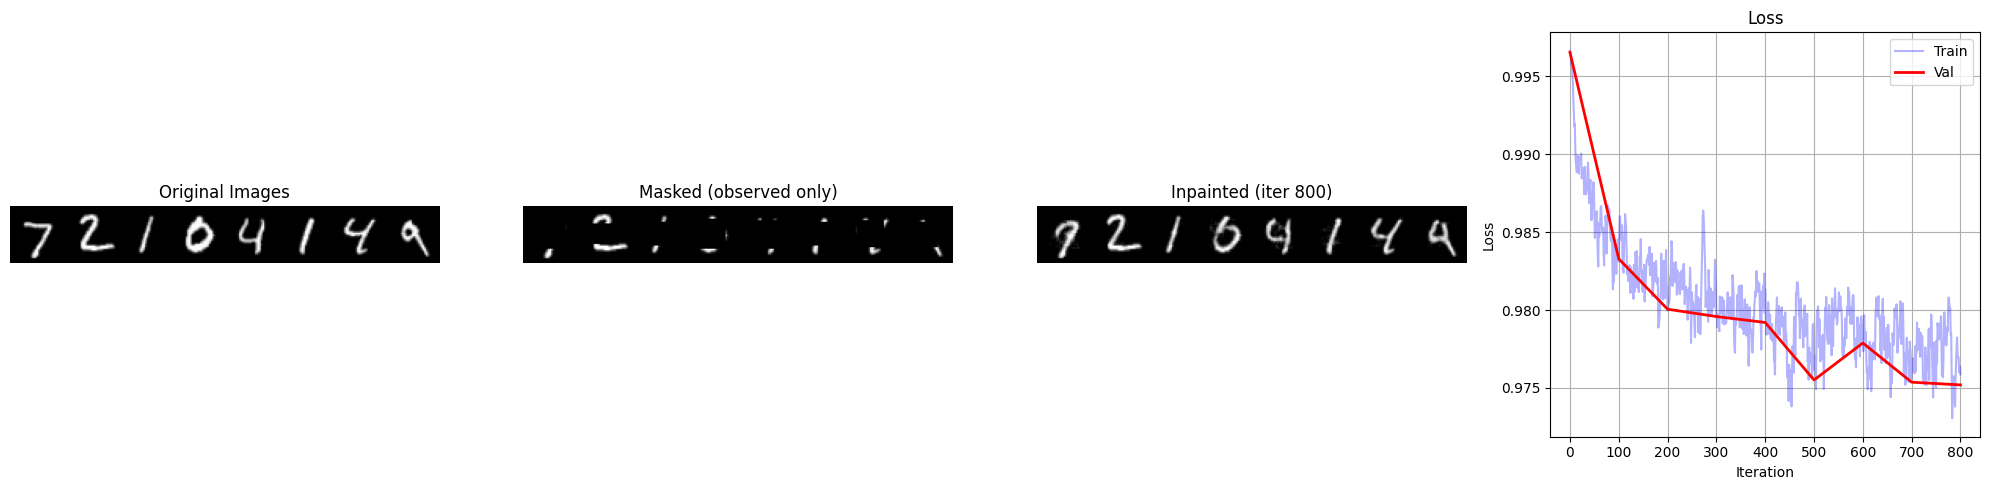

  4%|▍         | 801/20000 [13:44<31:51:25,  5.97s/it]

Iter 800 | Train Loss: 0.9759 | Val Loss: 0.9752


  4%|▍         | 860/20000 [14:33<5:24:06,  1.02s/it] 


KeyboardInterrupt: 

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create model
img_size = 32
net = SongUNet(
    img_resolution=img_size, 
    in_channels=1, 
    out_channels=1,
    model_channels=64,  # 64 or 128,  # Base multiplier for the number of channels.
    channel_mult=[2, 2, 2],    # Per-resolution multipliers for the number of channels.
    num_blocks=1,
).to(device)

print(f"Model parameters: {sum(p.numel() for p in net.parameters()):,}")

# Training config with RANDOM BOX SIZES!
min_box_size = 13  # Minimum box size (from 1 pixel...)
max_box_size = 19  # Maximum box size (up to full image size, which
train_params = {
    'max_iter': 20000,
    'batch_size': 128,
    'optimizer_args': {'lr': 2e-4, 'betas': (0.9, 0.99), 'eps': 1e-08},
    'num_workers': 4,
    'val_interval': 100,
    'val_batches': 32,
    'mask_type': 'random_box',  # Use random box sizes for each sample!
    'min_box_size': min_box_size,           # From 1 pixel...
    'max_box_size': max_box_size,          # ...to full 32x32 image
    'device': device,
    'img_size': img_size,
}

# Train
train_loss_history, val_loss_history = train_anisotropic(net, **train_params)

## Test and Visualize

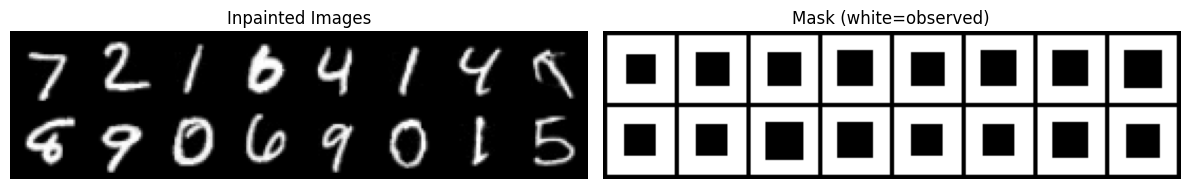

In [20]:
# Load model
min_box_size = 13  # Minimum box size (from 1 pixel...)
max_box_size = 19  # Maximum box size (up to full image size, which

checkpoint = torch.load('save/anisotropic_alpha_mf.pt', weights_only=False)
net.load_state_dict(checkpoint['model'])
net.eval()

# Test
batch_size = 16

test_mask = []
# min_box_size = 1
for _ in range(batch_size):
    box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    test_mask.append(generate_box_mask(1, 1, img_size, img_size, box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]
# test_mask = generate_box_mask(batch_size, 1, img_size, img_size, box_size=16, device=device)

test_dataset = MNIST(
    'data',
    train=False,
    transform=transforms.Compose(list(filter(None, [
        transforms.Resize((img_size, img_size)) if img_size is not None else None,
        transforms.Grayscale(),
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ]))),
    download=True
)
dataloader = NextDataLoader(
    test_dataset, batch_size, num_workers=4, prefetch_factor=2, pin_memory=True
)
img = next(dataloader)[0]  # [1, 1, 32, 32]

num_steps = 5
with torch.no_grad():
    samples = sample(net, test_mask, x_observed=img.to(device), device=device, num_steps=num_steps)

# Visualize
samples_vis = samples.detach().permute(0,2,3,1).clamp(0,1)
mask_vis = test_mask[:batch_size].permute(0,2,3,1).cpu()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Inpainted Images')
plt.imshow(grid(samples_vis.cpu()).squeeze())
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Mask (white=observed)')
plt.imshow(grid(mask_vis).squeeze())
plt.axis('off')

plt.tight_layout()
plt.show()